# 01 — Synthetic Dataset Generation

Generates **300** grayscale 64×64 images, each containing **3 non-overlapping white
rectangles**, annotated with COCO-format bounding boxes `[x, y, w, h]` normalised to
`[0, 1]`.

Splits into **train / val / test** (70 / 15 / 15 %) and saves each split as a `.npz`
file in `notebooks/data/`.

> Run this notebook **once** before opening `02_train_and_evaluate.ipynb`.

In [17]:
%pip install matplotlib --quiet
import sys, os

# Works whether Jupyter is launched from the project root or from notebooks/
project_root = (
    os.path.abspath('..')
    if os.path.basename(os.getcwd()) == 'notebooks'
    else os.path.abspath('.')
)
if project_root not in sys.path:
    sys.path.insert(0, project_root)


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [19]:
# ── configuration ──────────────────────────────────────────────────────────
N        = 2000         # total number of images
IMG_SIZE = 64           # image width and height in pixels
MAX_OBJ  = 3            # rectangles per image (fixed to avoid padding)
MIN_BOX  = 8            # minimum rectangle side in pixels
MAX_BOX  = 20           # maximum rectangle side in pixels
SEED     = 42
SPLIT    = (0.70, 0.15, 0.15)   # train / val / test fractions

# Resolve data directory relative to this notebook
_nb_dir  = (
    os.path.join(os.getcwd(), 'notebooks')
    if os.path.isdir(os.path.join(os.getcwd(), 'notebooks'))
    else os.getcwd()
)
DATA_DIR = os.path.join(_nb_dir, 'data')
# ───────────────────────────────────────────────────────────────────────────

## 1. Dataset Generation

Each image is black (0.0) with white (1.0) rectangles drawn on it.  
Rectangles are placed via rejection sampling to avoid overlap.  
Labels use **COCO format** `[x_left, y_top, width, height]` normalised to `[0, 1]`.

In [20]:
def _try_place(existing, img_size, min_b, max_b, rng):
    """Attempt to place one non-overlapping box; returns (x,y,w,h) or None."""
    for _ in range(200):
        w = int(rng.randint(min_b, max_b + 1))
        h = int(rng.randint(min_b, max_b + 1))
        x = int(rng.randint(1, img_size - w - 1))
        y = int(rng.randint(1, img_size - h - 1))
        if all(
            x + w <= bx or bx + bw <= x or y + h <= by or by + bh <= y
            for bx, by, bw, bh in existing
        ):
            return x, y, w, h
    return None


def generate_dataset(n, img_size=64, max_obj=3, min_b=8, max_b=20, seed=42):
    """Generate n grayscale images with 1–max_obj non-overlapping rectangles each.

    Labels use centre format [cx, cy, w, h] normalised to [0, 1] so that
    the model regresses the centre of each box — a more natural target for
    attention-based heads than the top-left corner.  Unused label slots are
    zero-padded ([0, 0, 0, 0]).
    """
    rng = np.random.RandomState(seed)
    images = np.zeros((n, img_size, img_size, 1), dtype=np.float32)
    labels = np.zeros((n, max_obj, 4), dtype=np.float32)

    for i in range(n):
        n_obj = int(rng.randint(1, max_obj + 1))  # random 1 … max_obj rectangles
        placed = []
        for j in range(n_obj):
            box = _try_place(placed, img_size, min_b, max_b, rng)
            if box is None:
                break
            x, y, w, h = box
            images[i, y:y + h, x:x + w, 0] = 1.0
            # Centre format: cx = x + w/2,  cy = y + h/2
            labels[i, j] = [
                (x + w / 2) / img_size,
                (y + h / 2) / img_size,
                w / img_size,
                h / img_size,
            ]
            placed.append(box)

    return images, labels


print('Generating dataset ...')
images, labels = generate_dataset(N, IMG_SIZE, MAX_OBJ, MIN_BOX, MAX_BOX, SEED)
print(f'Done.  images={images.shape}  labels={labels.shape}')
print('Label format: [cx, cy, w, h]  (centre, normalised to [0, 1])')

Generating dataset ...
Done.  images=(2000, 64, 64, 1)  labels=(2000, 3, 4)
Label format: [cx, cy, w, h]  (centre, normalised to [0, 1])


## 2. Train / Val / Test Split and Save

In [21]:
def split_dataset(images, labels, split=(0.70, 0.15, 0.15), seed=42):
    n   = len(images)
    idx = np.random.RandomState(seed).permutation(n)
    n_train = int(n * split[0])
    n_val   = int(n * split[1])
    tr  = idx[:n_train]
    va  = idx[n_train:n_train + n_val]
    te  = idx[n_train + n_val:]
    return (
        (images[tr], labels[tr]),
        (images[va], labels[va]),
        (images[te], labels[te]),
    )


(X_train, y_train), (X_val, y_val), (X_test, y_test) = split_dataset(
    images, labels, SPLIT, SEED
)

os.makedirs(DATA_DIR, exist_ok=True)
for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    np.savez_compressed(os.path.join(DATA_DIR, f'{name}.npz'), images=X, labels=y)

print(f'Saved to {DATA_DIR}/')
print(f'  train : {len(X_train):>4} images')
print(f'  val   : {len(X_val):>4} images')
print(f'  test  : {len(X_test):>4} images')

Saved to /Users/mykola/Projects/hungarian-loss/notebooks/data/
  train : 1400 images
  val   :  300 images
  test  :  300 images


## 3. Dataset Statistics

In [22]:
all_boxes = labels.reshape(-1, 4)               # (N * MAX_OBJ, 4)
all_boxes = all_boxes[all_boxes[:, 2] > 0]      # skip zero-padded slots
ws = all_boxes[:, 2] * IMG_SIZE
hs = all_boxes[:, 3] * IMG_SIZE
print('Box statistics (pixels):')
print(f'  width  — min={ws.min():.0f}  max={ws.max():.0f}  mean={ws.mean():.1f}')
print(f'  height — min={hs.min():.0f}  max={hs.max():.0f}  mean={hs.mean():.1f}')
print()
print('Sample label for image 0 (normalised [cx, cy, w, h]):')
for j, box in enumerate(labels[0]):
    print(f'  box {j}: {box}')

Box statistics (pixels):
  width  — min=8  max=20  mean=13.9
  height — min=8  max=20  mean=13.8

Sample label for image 0 (normalised [cx, cy, w, h]):
  box 0: [0.3203125 0.28125   0.171875  0.3125   ]
  box 1: [0.765625 0.390625 0.3125   0.1875  ]
  box 2: [0.109375  0.4765625 0.15625   0.203125 ]


## 4. Sample Visualisation

**Green** outlines are the ground-truth bounding boxes.

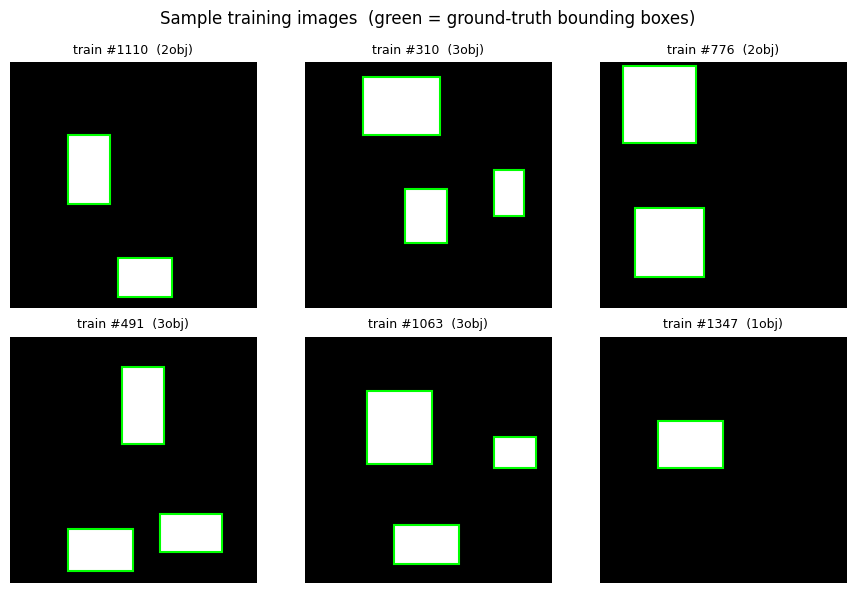

In [23]:
def _to_corner(cx, cy, w, h, img_size):
    """Convert centre [cx,cy,w,h] (normalised) to pixel corner (x,y,w,h).

    Subtracts 0.5 to account for matplotlib's pixel-centre convention:
    imshow centres pixel [r,c] at coordinate (c, r), so a numpy slice
    x:x+w occupies (x-0.5) … (x+w-0.5) in data coordinates.
    """
    px = (cx - w / 2) * img_size - 0.5
    py = (cy - h / 2) * img_size - 0.5
    return px, py, w * img_size, h * img_size


def draw_boxes(ax, image, boxes, color='lime', img_size=64, title=''):
    ax.imshow(image[:, :, 0], cmap='gray', vmin=0, vmax=1)
    for cx, cy, w, h in boxes:
        if w == 0:          # skip zero-padded slots
            continue
        px, py, pw, ph = _to_corner(cx, cy, w, h, img_size)
        rect = patches.Rectangle(
            (px, py), pw, ph,
            linewidth=1.5, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
    ax.set_title(title, fontsize=9)
    ax.axis('off')


sample_idx = np.random.RandomState(0).choice(len(X_train), 6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, i in zip(axes.flat, sample_idx):
    n_actual = int((y_train[i][:, 2] > 0).sum())
    draw_boxes(ax, X_train[i], y_train[i], title=f'train #{i}  ({n_actual}obj)')
fig.suptitle('Sample training images  (green = ground-truth bounding boxes)')
plt.tight_layout()
plt.show()

## 5. Bounding-Box Distribution

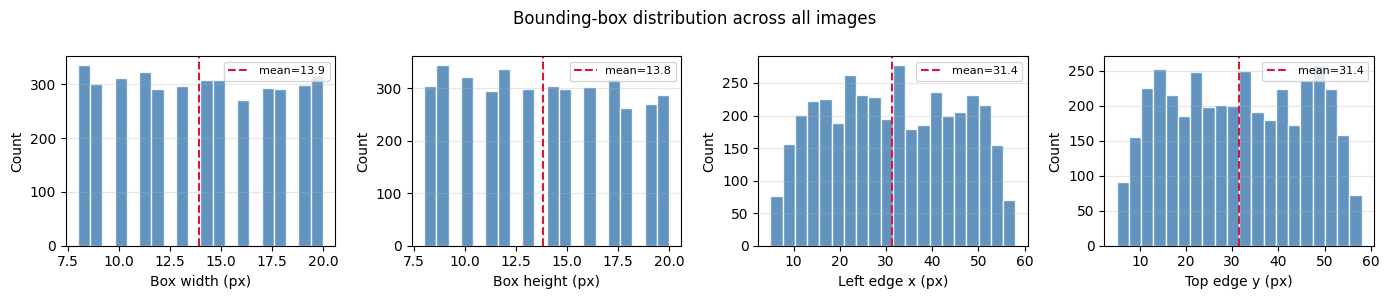

In [24]:
xs_px = all_boxes[:, 0] * IMG_SIZE
ys_px = all_boxes[:, 1] * IMG_SIZE

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, data, label in zip(
    axes,
    [ws, hs, xs_px, ys_px],
    ['Box width (px)', 'Box height (px)', 'Left edge x (px)', 'Top edge y (px)'],
):
    ax.hist(data, bins=20, edgecolor='white', color='steelblue', alpha=0.85)
    ax.axvline(data.mean(), color='crimson', linestyle='--', label=f'mean={data.mean():.1f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

fig.suptitle('Bounding-box distribution across all images')
plt.tight_layout()
plt.show()